Assume stock price follows geometric Brownian motion:
$$dS=\mu S dt + \sigma S dW$$

Terms:
- $S$: current value of process (stock price)
- $dS$: tiny change in S over a tiny time interval
- $\mu S dt$: deterministic drift. On average, expected annual growth rate is $\mu$ 
- $\sigma S dW$: random shock: 

<string>:32: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.


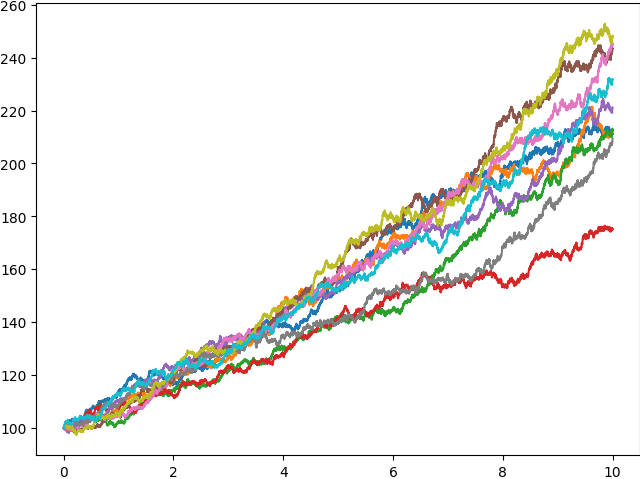

In [29]:
import numpy as np
import math
import matplotlib.pyplot as plt

rng = np.random.default_rng()
def calc_step(mu, sigma, S, time_step):
	z = rng.standard_normal()
	step = mu*S*time_step + sigma*S*math.sqrt(time_step)*z
	return step
def generate_path(mu, sigma, S, start, finish, intervals):
	price_path = np.zeros(intervals)
	price_path[0] = S
	time_step = (finish-start) / intervals
	for i in range(1, intervals):
		price_path[i] = (price_path[i-1] + 
		calc_step(mu, sigma, price_path[i-1], time_step))
	return price_path
	
#initialize parameters
mu = 0.08
sigma = 0.04
S_0 = 100
start = 0
finish = 10
intervals = 10000
paths = 10
#generate path
for i in range(paths):
	path = generate_path(mu, sigma, S_0, start, finish, intervals)
	x_values = np.linspace(start, finish, intervals)
	plt.plot(x_values, path)
plt.show()

Exact form solution is 
$$S_t = S_0\space \text{exp}[{(\mu - \frac{1}{2}\sigma^2)t + \sigma W_t}]$$